In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Setup path
root = os.path.abspath(os.path.join(".."))
if root not in sys.path: sys.path.append(root)

# 2. Nạp dữ liệu đã làm sạch
df = pd.read_csv("../data/processed/creditcard_cleaned.csv")

# 3. Chia X (biến độc lập) và y (biến mục tiêu)
X = df.drop(columns=['Class'])
y = df['Class']

# Chia tập Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [2]:
# 4. Khởi tạo mô hình Random Forest
# Chúng ta dùng 100 cây quyết định và cân bằng trọng số lớp
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 5. Huấn luyện (Quá trình này mất khoảng 30s - 1 phút tùy máy)
print("Đang huấn luyện mô hình, bạn đợi một chút nhé...")
model.fit(X_train, y_train)

# 6. Dự đoán trên tập Test
y_pred = model.predict(X_test)

Đang huấn luyện mô hình, bạn đợi một chút nhé...


BÁO CÁO KẾT QUẢ CHI TIẾT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

✅ THÀNH CÔNG!
1. Đã lưu ảnh tại: ../outputs/charts/confusion_matrix.png
2. Đã lưu mô hình tại: ../models/fraud_model.pkl


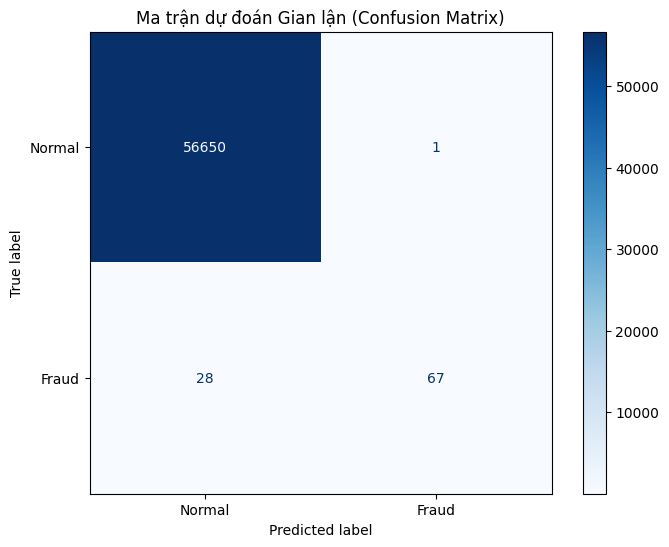

In [4]:
import joblib
import os

# 7. In báo cáo kết quả (Recall sẽ nằm ở dòng '1')
print("BÁO CÁO KẾT QUẢ CHI TIẾT:")
print(classification_report(y_test, y_pred))

# 8. Vẽ Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Ma trận dự đoán Gian lận (Confusion Matrix)')

# 9. TỰ ĐỘNG TẠO THƯ MỤC NẾU CHƯA CÓ (Để tránh lỗi FileNotFoundError)
path_chart = "../outputs/charts/"
path_model = "../models/"

os.makedirs(path_chart, exist_ok=True)
os.makedirs(path_model, exist_ok=True)

# 10. Lưu ảnh và mô hình
plt.savefig(os.path.join(path_chart, "confusion_matrix.png"))
joblib.dump(model, os.path.join(path_model, "fraud_model.pkl"))

print(f"✅ THÀNH CÔNG!")
print(f"1. Đã lưu ảnh tại: {path_chart}confusion_matrix.png")
print(f"2. Đã lưu mô hình tại: {path_model}fraud_model.pkl")
plt.show()